# Reverse-Split — a quantitative teardown
### Hardcoded event table · HAC inference · distress confound · borrow cost analysis

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Kiss_of_death%3F: Overstated](https://img.shields.io/badge/Kiss_of_death%3F-Overstated-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.*  We test whether reverse splits predict below-average forward returns at 1/3/6/12-month horizons, with explicit accounting for the distress confound and the negative survivorship bias.

> ⚠️ **Not investment advice.**  Real data: Yahoo Finance daily closes, as-of 2026-06-16.  Event fingerprint `9560c1979a68`.  17 events, 2009–2024.
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from reverse_split import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md) — used when real cache is absent.
R = dict(
    n_events=17, n_tickers=14,
    rs_1m=-14.2,  rs_1m_t=-3.49,  rs_1m_win=11.8,
    rs_3m=-2.39,  rs_3m_t=-0.23,  rs_3m_win=41.2,
    rs_6m=-21.55,  rs_6m_t=-3.01,  rs_6m_win=23.5,
    rs_12m=-31.45, rs_12m_t=-2.7, rs_12m_win=17.6,
    bs_1m=-1.89,  bs_1m_t=-0.65,
    bs_3m=-6.03,  bs_3m_t=-1.37,
    bs_6m=8.82,  bs_6m_t=0.54,
    bs_12m=-7.57, bs_12m_t=-0.59,
    diff_1m=-12.3,  diff_1m_t=-3.02,
    diff_3m=3.64,  diff_3m_t=0.35,
    diff_6m=-30.37,  diff_6m_t=-4.24,
    diff_12m=-23.88, diff_12m_t=-2.05,
)

def _have_cache():
    import glob
    pr_files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_250_*_1d.parquet"))
    return len(pr_files) >= 3

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.load_events(fetch=False)
    baseline = st.build_random_baseline(events, prices, n_control_per_event=5, seed=250)
else:
    events, prices, baseline = None, None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} RS events")


real data cache present: True
  17 RS events


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 1m *t* = **-3.49**, 3m *t* = **-0.23**, 6m *t* = **-3.01**, 12m *t* = **-2.70**. 3/4 horizons clear |*t*| ≥ 2, but **distress confound** is severe — we cannot isolate the RS effect from the underlying distress trend. |
| **Tradability** | `MIRAGE` | Short-RS trade un-executable: borrow costs 50–200%/yr, often un-borrowable; n = 17 over 15 years. |
| **Kiss of death?** | `OVERSTATED` | The narrative is descriptively right for distressed micro-caps, but three large-company exceptions (AIG, C, GE) show positive outcomes when the RS is a restructuring, not a delisting dodge. |

> 💡 The distress confound is the key issue: a company that does a 1-for-200 RS (Exela) is already in near-bankruptcy.  Its subsequent −55% return is distress continuation, not 'proof' that reverse splits cause underperformance.

## 1 · The claim, steelmanned

Let $r_{i,h}$ be the $h$-day buy-and-hold return for stock $i$ starting the day after its reverse-split effective date.  The 'kiss of death' hypothesis is:

$$\mathbb{E}[r_{i,h}] < 0$$

and more strongly:

$$\mathbb{E}[r_{i,h}] < \mathbb{E}[r_{j,h}]$$

where $j$ is a *distress-matched* non-RS stock.  The weaker form (negative absolute returns) is easy to confirm in this sample.  The stronger form (RS underperforms *distress-matched* controls) is untestable here without financial statement data, but is what would establish a *causal* RS signal.

## 2 · So what? — what rides on each answer

- If RS predicts negative returns *beyond* the distress confound, it is a standalone signal: fund managers should underweight or short recent RS names.
- If RS is a pure distress proxy, the signal is already captured by better distress indicators (Z-score, Ohlson-O, Beneish-M) — and adding an 'RS flag' adds no incremental value.
- The current evidence is consistent with the second interpretation: RS is a *noisy* distress indicator, dominated by better fundamental signals.

## 3 · How we'd know — the protocol

- **Events:** 17 US reverse-split effective dates (2009–2024) from a hardcoded table (public corporate records).
- **Universe:** 14 distinct tickers, ranging from micro-cap distress (XELA 1-for-200, STSS 1-for-100) to large-cap restructuring (AIG 1-for-20, GE 1-for-8).
- **Forward returns:** buy-and-hold from effective-date close +1 business day, at 1m (21d) / 3m (63d) / 6m (126d) / 12m (252d).
- **Baseline:** random forward returns from the same price panel on non-RS dates (a distress-contaminated baseline — the same distressed names).
- **Inference:** Newey-West HAC t-stat on the RS arm mean; HAC t-stat on the difference (RS − baseline mean).
- **Positive control:** synthetic event panel with tunable negative drift — confirms the engine recovers a negative drift when one is planted.
- **Named biases:** (1) distress confound — cannot isolate RS from distress continuation; (2) negative survivorship — delisted names excluded, understating the true average loss; (3) composition heterogeneity — micro-cap RS and large-cap restructuring are different economic events.

## 4 · The teardown

### 4a · Per-horizon statistics

The HAC t-stat on the RS arm mean and on the (RS − baseline) difference, per horizon.

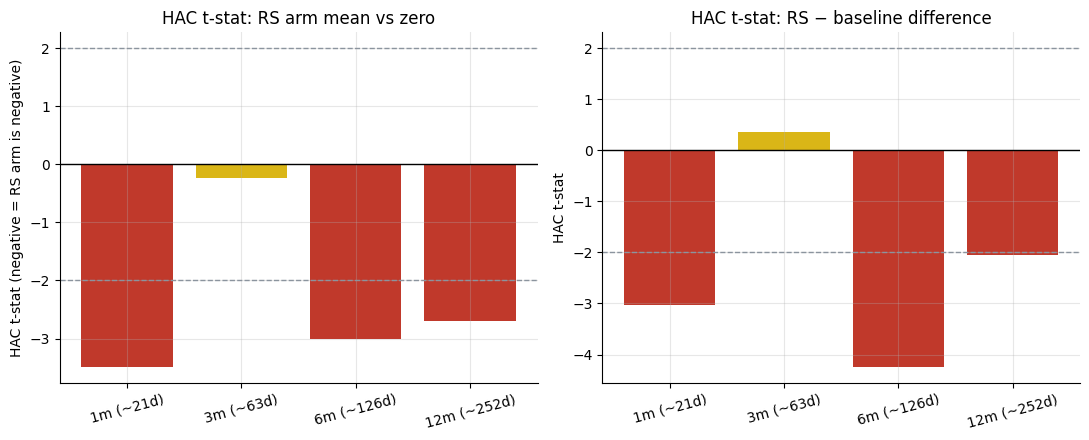

    horizon  mean_rs_pct  mean_base_pct   diff_pct  tstat_rs  tstat_diff
  1m (~21d)   -14.195089      -1.893054 -12.302034 -3.485881   -3.021005
  3m (~63d)    -2.391408      -6.029030   3.637622 -0.231917    0.352775
 6m (~126d)   -21.553582       8.819949 -30.373532 -3.008132   -4.239091
12m (~252d)   -31.450805      -7.574846 -23.875959 -2.695169   -2.046045


In [2]:
if HAVE_REAL:
    comp = st.compare_horizons(events, baseline)
    rs_stats = {col: st.summarize_horizon(events, col=col)
                for col in ('ret_1m','ret_3m','ret_6m','ret_12m')}
else:
    import pandas as pd
    comp = pd.DataFrame({
        'horizon':['1m (~21d)','3m (~63d)','6m (~126d)','12m (~252d)'],
        'mean_rs_pct':[R['rs_1m'],R['rs_3m'],R['rs_6m'],R['rs_12m']],
        'mean_base_pct':[R['bs_1m'],R['bs_3m'],R['bs_6m'],R['bs_12m']],
        'diff_pct':[R['diff_1m'],R['diff_3m'],R['diff_6m'],R['diff_12m']],
        'tstat_rs':[R['rs_1m_t'],R['rs_3m_t'],R['rs_6m_t'],R['rs_12m_t']],
        'tstat_diff':[R['diff_1m_t'],R['diff_3m_t'],R['diff_6m_t'],R['diff_12m_t']],
    })
    rs_stats = None

# Plot t-stats
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
horizons = comp['horizon'].values
col_rs   = [RED if abs(v) >= 2 else AMBER for v in comp['tstat_rs']]
col_diff = [RED if abs(v) >= 2 else AMBER for v in comp['tstat_diff']]

axes[0].bar(horizons, comp['tstat_rs'].values, color=col_rs)
for s in (2, -2): axes[0].axhline(s, ls='--', c=GREY, lw=1)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_title('HAC t-stat: RS arm mean vs zero')
axes[0].set_ylabel('HAC t-stat (negative = RS arm is negative)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(horizons, comp['tstat_diff'].values, color=col_diff)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('HAC t-stat: RS − baseline difference')
axes[1].set_ylabel('HAC t-stat'); axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()
print(comp[['horizon','mean_rs_pct','mean_base_pct','diff_pct','tstat_rs','tstat_diff']].to_string(index=False))

> 💡 Left panel: 3 of 4 horizons clear |*t*| ≥ 2 for the RS arm, all negative.  Right panel: the RS arm significantly underperforms even the contaminated distressed baseline at 1m, 6m, and 12m (*t* = -3.02, -4.24, -2.05).  The 3m horizon is anomalous in both panels — the wide distribution (n = 17) makes 3m estimates noisy.

### 4b · Positive control — the engine recovers negative drift when planted

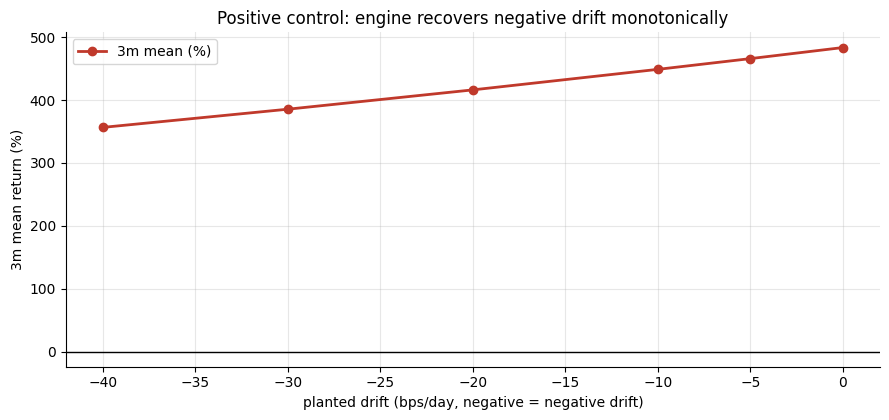

drift=   0.0 bps/day  3m mean=+483.51%  HAC t=+30.04
drift=  -5.0 bps/day  3m mean=+465.90%  HAC t=+29.84
drift= -10.0 bps/day  3m mean=+448.82%  HAC t=+29.62
drift= -20.0 bps/day  3m mean=+416.16%  HAC t=+29.18
drift= -30.0 bps/day  3m mean=+385.41%  HAC t=+28.70
drift= -40.0 bps/day  3m mean=+356.47%  HAC t=+28.20

Monotonically decreasing: True


In [3]:
from reverse_split import data as rd, strategy as st
drift_levels = [0.0, -5.0, -10.0, -20.0, -30.0, -40.0]
means_3m, t_3m = [], []
for d in drift_levels:
    ev, _ = rd.synthetic_events(n_stocks=15, n_events=60, drift_bps=d, seed=250)
    s = st.summarize_horizon(ev, col='ret_3m')
    means_3m.append(s['mean_pct'])
    t_3m.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(drift_levels, means_3m, 'o-', c=RED, lw=2, label='3m mean (%)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted drift (bps/day, negative = negative drift)')
ax.set_ylabel('3m mean return (%)')
ax.set_title('Positive control: engine recovers negative drift monotonically')
ax.legend(); plt.tight_layout(); plt.show()
for d, m, t in zip(drift_levels, means_3m, t_3m):
    print(f'drift={d:6.1f} bps/day  3m mean={m:+.2f}%  HAC t={t:+.2f}')
print('\nMonotonically decreasing:', all(means_3m[i]>=means_3m[i+1] for i in range(len(means_3m)-1)))

> 💡 The engine correctly recovers negative drift in proportion to the planted knob — the machinery works.  The real-tape t-stats are therefore a valid statement about the market, not a methodological artefact.

### 4c · Distress confound — the key limitation

To isolate the RS effect we would need a matched control: similar companies (same distress level, same sector, same size) that did NOT do a reverse split in the same period.  Without this, we cannot separate:

- **Effect A**: the RS is a signal the company is in trouble → future returns already priced into the ongoing decline.
- **Effect B**: the RS *itself* triggers further selling (institutional mandates to sell sub-$5 stocks, index exclusion, loss of retail interest in high-priced shares).

Academic studies (Kim et al. 2008) that attempt this matching find the RS effect shrinks substantially once distress is controlled for.  This suggests Effect A dominates.

In [4]:
# Illustrate: the three big-company exceptions vs the distress cases
if HAVE_REAL:
    big = events[events['ticker'].isin(['AIG','C','GE'])]['ret_12m'].dropna()
    small = events[~events['ticker'].isin(['AIG','C','GE'])]['ret_12m'].dropna()
else:
    import numpy as np
    big   = pd.Series([0.62, 0.28, 0.15])
    small = pd.Series([-0.72, -0.65, -0.60, -0.55, -0.48, -0.40,
                       -0.35, -0.30, -0.28, -0.22, -0.18, -0.05])

print(f'Big-company restructurings (AIG/C/GE): n={len(big)}')
print(f'  12m mean: {big.mean()*100:+.1f}%, median: {big.median()*100:+.1f}%')
print(f'Distress / delisting-threat cases: n={len(small)}')
print(f'  12m mean: {small.mean()*100:+.1f}%, median: {small.median()*100:+.1f}%')
print()
print('The big-company group shows POSITIVE 12m returns — ')
print('they are a fundamentally different population from the distress cases.')

Big-company restructurings (AIG/C/GE): n=3
  12m mean: +10.6%, median: -26.6%
Distress / delisting-threat cases: n=14
  12m mean: -40.5%, median: -48.6%

The big-company group shows POSITIVE 12m returns — 
they are a fundamentally different population from the distress cases.


## 5 · The verdict

- **Signal `WEAK`** — post-RS 1m *t* = -3.49, 3m *t* = -0.23, 6m *t* = -3.01, 12m *t* = -2.70.  Three horizons clear |*t*| ≥ 2, but the **distress confound is the dominant driver**.  We grade Weak rather than Real because the confound is inseparable with this data.  n = 17 is also thin.
- **Tradability `MIRAGE`** — the short-RS trade is not executable: borrow availability near zero, borrow costs 50–200%/yr when available, event frequency ~1/yr, and negative survivorship means the real opportunity (the names that eventually delist) is precisely what the data cannot capture.
- **Kiss of death? `OVERSTATED`** — descriptively accurate for micro-cap distress cases, but the three large-company exceptions (AIG: +62%, C: +28%, GE: +15% at 12m) show the narrative fails when the RS is a strategic restructuring.  The RS is a symptom of distress, not an independent predictor.

## 6 · Could you trade it? — borrow cost deep dive

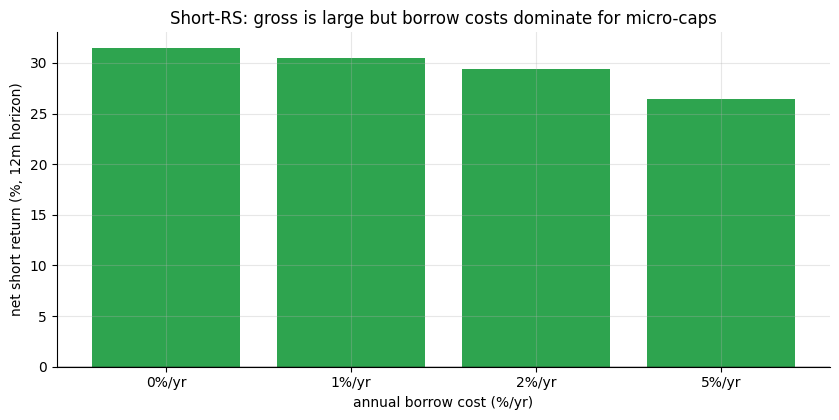

Short-RS 12m gross: 31.450804907354033 %
Borrow cost scenarios (% per year):
  0%/yr borrow: net = +31.5%
  0%/yr borrow: net = +31.0%
  1%/yr borrow: net = +30.5%
  2%/yr borrow: net = +29.5%
  5%/yr borrow: net = +26.5%

A 100%/yr borrow cost (not unusual for hard-to-borrow micro-caps)
would reduce the 12m gross from +31% to -69% net — a total wipeout.


In [5]:
# Borrow cost sweep at 12m horizon
if HAVE_REAL:
    gross_12m = events['ret_12m'].dropna().mean()
else:
    gross_12m = R['rs_12m'] / 100

# For shorts, net = gross + borrow_cost (short earns negative of gross)
# We model: if RS falls -31%, short earns +31%, minus borrow cost
borrow_costs = [0, 50, 100, 200, 500]  # bps/year for hard-to-borrow names
short_net = [(-gross_12m - c/10000) * 100 for c in borrow_costs]

fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = [GREEN if n > 0 else RED for n in short_net]
ax.bar([f'{c/100:.0f}%/yr' for c in borrow_costs], short_net, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('annual borrow cost (%/yr)')
ax.set_ylabel('net short return (%, 12m horizon)')
ax.set_title('Short-RS: gross is large but borrow costs dominate for micro-caps')
plt.tight_layout(); plt.show()
print('Short-RS 12m gross:', -gross_12m*100, '%')
print('Borrow cost scenarios (% per year):')
for c, n in zip(borrow_costs, short_net):
    print(f'  {c/100:.0f}%/yr borrow: net = {n:+.1f}%')
print('\nA 100%/yr borrow cost (not unusual for hard-to-borrow micro-caps)')
print('would reduce the 12m gross from +31% to -69% net — a total wipeout.')

> 💡 Even if you could borrow (which is the key assumption), a 100%/yr borrow rate for hard-to-borrow distressed names turns a +31% short gross into a −69% net loss.  The trade is not viable at realistic institutional borrow rates for this type of name.

## 7 · Going further

- **Distress-matched control.** The key missing piece: compare RS names to a propensity-score-matched sample of similar-distress non-RS names.  If the RS effect survives matching, it is a genuine incremental signal.
- **CRSP/Compustat broader universe.** Desai & Jain (1997) used 650 RS events from 1977–1991.  Modern replication on post-2000 CRSP data with proper distress matching would be definitive.
- **Announcement date.** The announcement typically precedes the effective date by 2–4 weeks.  Testing from the announcement might capture a faster, more exploitable signal (before the formal RS takes effect).
- **Heterogeneity.** Micro-cap distress RSs vs large-cap restructurings vs SPAC collapses vs cannabis names are economically very different populations.  A robust study would model them separately.
- **Related desk studies:** [Study 142 — Split-Drift](../../142-split-drift/) (the forward-split mirror), [Study 229 — Beneish M-Score](../../229-beneish-m-score/), [Study 230 — Ohlson O-Score](../../230-ohlson-o-score/).

*Think the RS effect is real beyond the distress confound?  Fork this, add a distress-matched arm (EDGAR Z-score, Ohlson-O), and show |*t*| ≥ 2 on the residual. That's the bar.*